In [63]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import pandas_datareader.data as web
import os
import re
import requests
import json
from datetime import datetime
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

In [3]:
# source folder
folder_name = 'Factset_Price_History_Downloads'
terms = [2, 3, 5, 7, 10, 20 , 30 ]

# iterate over the sub folders to access the files
yr_files = { f'{term}yr': os.listdir(f'{folder_name}/us_{term}yr') for term in terms }

all_dfs = {}
all_by_yr = None
for term in terms:
    # start with the first df
    all_by_yr = pd.read_excel(f'{folder_name}/us_{term}yr/' + yr_files[f"{term}yr"][0], skiprows=2)
    all_by_yr.drop(columns = [ 'Composite'], inplace=True)
    all_by_yr.sort_values(by='Date', inplace = True)

    ## concat the rest of the dfs.
    for file in yr_files[f"{term}yr"][1:]:
      df = pd.read_excel(f'{folder_name}/us_{term}yr/{file}', skiprows=2)
      df.dropna(how='all', inplace=True)
      df.sort_values(by='Date', inplace=True)
      df.drop(columns = ['Date', 'Composite'], inplace=True)
      all_by_yr= pd.concat([all_by_yr, df], axis = 1)
      df = None

    all_dfs[f"{term}yr"] = all_by_yr
    all_by_yr = None

In [4]:
# get the CUSIPs
page_size   = 100
page_number = 1
url = 'https://api.fiscaldata.treasury.gov/services/api/fiscal_service/v1/accounting/od/auctions_query'

def get_treasuries(url, params):
    '''
     Function to pull data CUSIP data from the US Treasury
    '''

    resp=requests.get( url = url, params=params)
    data_dict = json.loads(resp.text)
    if  data_dict.get('data') is None:
      return None
    df = pd.DataFrame(data_dict['data'])
    df.sort_values(by="auction_date", inplace=True)
    return df

def extract_cusip(text):
    '''
     Function to extract the cusip from the column name
    '''
    substr = re.search(r'\((.+)\)',text )
    if substr:
        val= substr.group(1) # Extract the matched substring
        return val

    return None

In [5]:
processed_dfs = {}


for term in terms:
    ## Using 252 and the number of trading days + 20 days as a buffer for any unusual years
    ## Capturing the length of all non-nan values for each CUSIP's Column then recording the index of the column
    length_issues_idxs  = np.argwhere(len(all_dfs[f'{term}yr']) - all_dfs[f'{term}yr'].isna().sum().values > term * 252 + 20  )
    length_issues_idxs  = np.array( [ x[0] for x in length_issues_idxs])
    affected_cusips     = [extract_cusip(t) for t in list(all_dfs[f'{term}yr'].iloc[: , length_issues_idxs[ 1:]].columns)]
    params = { 'fields': 'cusip,security_term,security_type,issue_date,auction_date',
                  'filter': f'cusip:in:({",".join(affected_cusips)})',
                  'page[number]' : f'{page_number}',
                  'page[size]'   : f'{page_size}'
            }


    if len(length_issues_idxs) > 1 :
        issues_df = get_treasuries(url, params)
        issues_df.sort_values(by=['cusip', 'issue_date'])

        #Exclude any CUSIP that started before 2000. We will keep the time series that started after 2000.
        cusips_filter   = issues_df['cusip'][issues_df.issue_date < '2000-01-01']
        affected_cusips = issues_df['cusip'][~issues_df.cusip.isin( cusips_filter)].drop_duplicates().values
        print('Affected Cusips : ', affected_cusips)
        #Save for future reference
        issues_df.to_csv(f'Factset_Price_History_Reused_Cusips/us_treasuries/reused_cusips_{term}yr.csv', index=False)

    #Drop The CUSIP from the shorter length DataFrame

    mask = []
    for i, col  in enumerate(all_dfs[f'{term}yr'].iloc[:, 1:].columns):
      for cusip in affected_cusips:
          if f'({cusip})' in col:
            mask.append(i)
    print('Number of affected cusips:' , len(mask))
    cols_ser = pd.Series(all_dfs[f'{term}yr'].iloc[:, 1:].columns)
    cols_to_drop = cols_ser.iloc[mask].values
    df = all_dfs[f'{term}yr'].drop(columns= cols_to_drop)
    processed_dfs[f'{term}yr'] = df

Affected Cusips :  ['912828ST8' '912828SY7' '912828TM2' '912828TS9' '912828TW0' '912828UR9'
 '912828C57' '912828WG1' '912828F62']
Number of affected cusips: 9
Affected Cusips :  ['912828AN0' '912828TY6' '91282CEU1']
Number of affected cusips: 3
Affected Cusips :  ['912828CZ1' '912828RE2' '912828RH5' '912828M80' '912828N30' '912828W71'
 '912828XT2' '912828Z78']
Number of affected cusips: 8
Number of affected cusips: 0
Number of affected cusips: 0
Affected Cusips :  ['912810FR4']
Number of affected cusips: 1
Number of affected cusips: 0


In [6]:
processed_dfs.keys()

dict_keys(['2yr', '3yr', '5yr', '7yr', '10yr', '20yr', '30yr'])

In [11]:
processed_dfs['2yr']

,Date,United States Treasury Notes 0.25% 30-SEP-2023 (91282CDA6),United States Treasury Notes 0.125% 31-AUG-2023 (91282CCU3),United States Treasury Notes FRN 31-JUL-2023 (91282CCQ2),United States Treasury Notes 0.125% 31-JUL-2023 (91282CCN9),United States Treasury Notes 0.125% 30-JUN-2023 (91282CCK5),United States Treasury Notes 0.125% 31-MAY-2023 (91282CCD1),United States Treasury Notes FRN 30-APR-2023 (91282CBY6),United States Treasury Notes 0.125% 30-APR-2023 (91282CBX8),United States Treasury Notes 0.125% 31-MAR-2023 (91282CBU4),...,Government of the United States of America 5.75% 31-OCT-2002 (9128273L4),Government of the United States of America 6.0% 30-SEP-2002 (9128276L1),Government of the United States of America 6.125% 31-AUG-2002 (9128276K3),Government of the United States of America 6.25% 31-JUL-2002 (9128276H0),Government of the United States of America 6.375% 30-JUN-2002 (9128276F4),Government of the United States of America 6.625% 31-MAY-2002 (9128276E7),Government of the United States of America 6.375% 30-APR-2002 (9128276C1),Government of the United States of America 6.5% 31-MAR-2002 (9128276B3),Government of the United States of America 6.5% 28-FEB-2002 (9128276A5),Government of the United States of America 6.375% 31-JAN-2002 (9128275X6)
0,1999-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6417,2025-07-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6418,2025-07-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6419,2025-07-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6420,2025-07-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# load the fred data
df_fred = pd.read_parquet("FRED_Data/fred_raw.parquet")
df_fred.head()

,id,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,group_popularity,notes
495,EXPINF1YR,1-Year Expected Inflation,1982-01-01,2025-07-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2025-07-15 14:33:09-05,65,65,The Federal Reserve Bank of Cleveland estimate...
490,REAINTRATREARAT1YE,1-Year Real Interest Rate,1982-01-01,2025-07-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2025-07-15 14:33:03-05,65,65,The Federal Reserve Bank of Cleveland estimate...
45,T10YIEM,10-Year Breakeven Inflation Rate,2003-01-01,2025-06-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2025-07-01 16:01:06-05,47,89,The breakeven inflation rate represents a meas...
419,EXPINF10YR,10-Year Expected Inflation,1982-01-01,2025-07-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2025-07-15 14:33:10-05,67,67,The Federal Reserve Bank of Cleveland estimate...
107,REAINTRATREARAT10Y,10-Year Real Interest Rate,1982-01-01,2025-07-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2025-07-15 14:33:03-05,80,80,The Federal Reserve Bank of Cleveland estimate...


In [9]:
symbols = [
    "FEDFUNDS", "DGS10", "T5YIE", "T10YIE", "T10Y3M", "THREEFYTP10", "REAINTRATREARAT10Y", "VIXCLS", "EFFR", "CPILFESL",
    "USEPUINDXD", "GEPUCURRENT", 'DFII10', 'DGS10', 'DTWEXBGS', 'DCOILWTICO', 'DGS2', 'DGS5',
]

fred_series = {
    'T5YIE': '5_Year_Inflation_Expectation',
    'T10YIE': '10_Year_Inflation_Expectation',
    'T10Y3M': '10_Year_3_Year_Spread',
    'FEDFUNDS': 'Fed_Funds_Rate',
    'THREEFYTP10': '10_Year_Term_Premium',
    'REAINTRATREARAT10Y': '10yr_real_intrest',
    'EFFR': 'Effective_Fed_Funds_Rate_Daily',
    'CPILFESL': 'CPI_Core',
    'USEPUINDXD': 'Economic_Policy_Uncertainty_US',
    'GEPUCURRENT': 'Global_EPU_Index',
    'REAINTRATREARAT10Y': 'Real_10-Year_Yield',
    'DFII10': '10_Year_TIPS_Yield',
    'DGS10': '10_Year_Treasury_Yield',
    'DTWEXBGS': 'Dollar_Index',
    'DCOILWTICO': 'Crude_Oil_Price_WTI',
    'DGS2': '2_Year_Treasury_Yield',
    'DGS5': '5_Year_Treasury_Yield',
    'WTISPLC': 'WTI_Spot_price',
    'INDPRO': 'Industrial_Production',
    'IPMAN': 'Manufacturing_Production',
    'CBBTCUSD': 'Bitcoin_spot_price',
    'M2SL': 'Money_supply'

}
df_fred[df_fred['id'].isin(symbols)]

,id,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,group_popularity,notes
107,REAINTRATREARAT10Y,10-Year Real Interest Rate,1982-01-01,2025-07-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2025-07-15 14:33:03-05,80,80,The Federal Reserve Bank of Cleveland estimate...
215,VIXCLS,CBOE Volatility Index: VIX,1990-01-02,2025-07-23,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2025-07-24 08:37:07-05,75,75,VIX measures market expectation of near term v...
76,CPILFESL,Consumer Price Index for All Urban Consumers: ...,1957-01-01,2025-06-01,Monthly,M,Index 1982-1984=100,Index 1982-1984=100,Seasonally Adjusted,SA,2025-07-15 07:40:45-05,82,82,"The ""Consumer Price Index for All Urban Consum..."
165,EFFR,Effective Federal Funds Rate,2000-07-03,2025-07-23,Daily,D,Percent,%,Not Seasonally Adjusted,NSA,2025-07-24 08:01:04-05,77,77,For additional historical federal funds rate d...
2,FEDFUNDS,Federal Funds Effective Rate,1954-07-01,2025-06-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2025-07-01 15:17:14-05,98,99,Daily Federal Funds Rate from 1928-1954 (http...
420,THREEFYTP10,Term Premium on a 10 Year Zero Coupon Bond,1990-01-02,2025-07-18,Daily,D,Percent,%,Not Seasonally Adjusted,NSA,2025-07-22 14:02:03-05,67,67,Kim and Wright (2005) produced this data by fi...


### 📊 Macroeconomic Indicators and FRED Symbols for U.S. Government Bonds

| **Indicator**                          | **FRED Symbol**         | **Description**                                      |
|---------------------------------------|--------------------------|------------------------------------------------------|
| Fed Funds Effective Rate              | `FEDFUNDS`              | Benchmark short-term interest rate                   |
| 10-Year Treasury Yield                | `DGS10`                 | Long-term yield signal                               |
| 5-Year Breakeven Inflation            | `T5YIE`                 | 5-year inflation expectation                         |
| 10-Year Breakeven Inflation           | `T10YIE`                | 10-year inflation expectation                        |
| Yield Curve Spread (10Y minus 3M)     | `T10Y3M`                | Indicator of growth/inversion                        |
| 10-Year Term Premium                  | `THREEFYTP10`           | Premium over short rates for duration risk           |
| 10-Year Real Interest Rate Estimate   | `REAINTRATREARAT10Y`    | Real rate adjusted for inflation expectations        |


In [10]:
# get the series
# Pull data from FRED and store in a dictionary
start = datetime(1950, 1, 1)
end = datetime(2025, 7, 28)
data = {}
for symbol, label in fred_series.items():
    try:
        data[label] = web.DataReader(symbol, 'fred', start, end)
    except Exception as e:
        print(f"Failed to fetch {label} ({symbol}): {e}")
df_all = pd.concat(data.values(), axis=1)
df_all.columns = data.keys()

In [11]:
df_all.head()

,5_Year_Inflation_Expectation,10_Year_Inflation_Expectation,10_Year_3_Year_Spread,Fed_Funds_Rate,10_Year_Term_Premium,Real_10-Year_Yield,Effective_Fed_Funds_Rate_Daily,CPI_Core,Economic_Policy_Uncertainty_US,Global_EPU_Index,...,10_Year_Treasury_Yield,Dollar_Index,Crude_Oil_Price_WTI,2_Year_Treasury_Yield,5_Year_Treasury_Yield,WTI_Spot_price,Industrial_Production,Manufacturing_Production,Bitcoin_spot_price,Money_supply
DATE,,,,,,,,,,,,,,,,,,,,,
1950-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.57,14.0049,NaN,NaN,NaN
1950-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.57,14.0586,NaN,NaN,NaN
1950-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.57,14.5156,NaN,NaN,NaN
1950-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.57,14.9995,NaN,NaN,NaN
1950-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.57,15.3489,NaN,NaN,NaN


In [12]:
df_all.to_parquet("macro_economical_data.parquet")

In [15]:
for key, value in processed_dfs.items():
    print(f"persisting -> {key}")
    try:
        value.to_parquet(f"{key}.parquet")
    except Exception as e:
        print(f"Failed to persist {key}: {e}")

persisting -> 2yr
persisting -> 3yr
persisting -> 5yr
Failed to persist 5yr: Duplicate column names found: ['Date', 'United States Treasury Notes 1.125% 28-FEB-2021 (912828P87)', 'United States Treasury Notes 1.375% 31-JAN-2021 (912828N89)', 'United States Treasury Notes 1.75% 31-DEC-2020 (912828N48)', 'United States Treasury Notes 1.625% 30-NOV-2020 (912828M98)', 'United States Treasury Notes 1.375% 31-OCT-2020 (912828L99)', 'United States Treasury Notes 1.375% 30-SEP-2020 (912828L65)', 'United States Treasury Notes 1.375% 31-AUG-2020 (912828L32)', 'United States Treasury Notes 1.375% 30-APR-2020 (912828K58)', 'United States Treasury Notes 0.125% 15-APR-2020 (912828K33)', 'United States Treasury Notes 1.375% 31-MAR-2020 (912828J84)', 'United States Treasury Notes 1.375% 29-FEB-2020 (912828J50)', 'United States Treasury Notes 1.375% 31-JUL-2018 (912828VQ0)', 'United States Treasury Notes 1.375% 30-JUN-2018 (912828VK3)', 'United States Treasury Notes 1.0% 31-MAY-2018 (912828VE7)', 'Unit

In [3]:
# read in alll the persisted data
def read_persisted_data(terms: list[int]):
    """
    Function to read all the persisted data from parquet files
    """
    processed_dfs = {}
    for term in terms:
        try:
            df = pd.read_parquet(f"{term}yr.parquet")
            processed_dfs[term] = df
        except Exception as e:
            print(f"Failed to read {term}yr data: {e}")
    return processed_dfs

terms = [2, 3, 20, 30]
processed_dfs = read_persisted_data(terms=terms)
print(processed_dfs.keys())


dict_keys([2, 3, 20, 30])


In [4]:
processed_dfs[2].head()

,Date,United States Treasury Notes 0.25% 30-SEP-2023 (91282CDA6),United States Treasury Notes 0.125% 31-AUG-2023 (91282CCU3),United States Treasury Notes FRN 31-JUL-2023 (91282CCQ2),United States Treasury Notes 0.125% 31-JUL-2023 (91282CCN9),United States Treasury Notes 0.125% 30-JUN-2023 (91282CCK5),United States Treasury Notes 0.125% 31-MAY-2023 (91282CCD1),United States Treasury Notes FRN 30-APR-2023 (91282CBY6),United States Treasury Notes 0.125% 30-APR-2023 (91282CBX8),United States Treasury Notes 0.125% 31-MAR-2023 (91282CBU4),...,Government of the United States of America 5.75% 31-OCT-2002 (9128273L4),Government of the United States of America 6.0% 30-SEP-2002 (9128276L1),Government of the United States of America 6.125% 31-AUG-2002 (9128276K3),Government of the United States of America 6.25% 31-JUL-2002 (9128276H0),Government of the United States of America 6.375% 30-JUN-2002 (9128276F4),Government of the United States of America 6.625% 31-MAY-2002 (9128276E7),Government of the United States of America 6.375% 30-APR-2002 (9128276C1),Government of the United States of America 6.5% 31-MAR-2002 (9128276B3),Government of the United States of America 6.5% 28-FEB-2002 (9128276A5),Government of the United States of America 6.375% 31-JAN-2002 (9128275X6)
0,1999-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# load the macroeconomic data
df_macro = pd.read_parquet("macro_economical_data.parquet")
df_macro.head()

,5_Year_Inflation_Expectation,10_Year_Inflation_Expectation,10_Year_3_Year_Spread,Fed_Funds_Rate,10_Year_Term_Premium,Real_10-Year_Yield,Effective_Fed_Funds_Rate_Daily,CPI_Core,Economic_Policy_Uncertainty_US,Global_EPU_Index,...,10_Year_Treasury_Yield,Dollar_Index,Crude_Oil_Price_WTI,2_Year_Treasury_Yield,5_Year_Treasury_Yield,WTI_Spot_price,Industrial_Production,Manufacturing_Production,Bitcoin_spot_price,Money_supply
DATE,,,,,,,,,,,,,,,,,,,,,
1950-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.57,14.0049,NaN,NaN,NaN
1950-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.57,14.0586,NaN,NaN,NaN
1950-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.57,14.5156,NaN,NaN,NaN
1950-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.57,14.9995,NaN,NaN,NaN
1950-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.57,15.3489,NaN,NaN,NaN


In [21]:
# REset the index
# df_macro.reset_index(inplace=True)
# create a seperate dataframe for the macroeconomic columns then calcualte the log returns for each column
macro_data = {}
inf_columns = [
    '10_Year_3_Year_Spread', '10_Year_Term_Premium', '10_Year_TIPS_Yield'
]
for col in df_macro.columns:
    if col == 'DATE':
        continue  # Skip the DATE column, we will use it as an index
    # drop the null values
    df_tmp = df_macro[['DATE', col]].dropna()
    # Add alpha to the coulumns to avoid division by zero errors
    df_tmp[col] = df_tmp[col] + 0.01  # Adding
    # calculate the log returns
    if col in inf_columns:
        # For inflation related columns, we will use the log returns
        df_tmp[f'{col}_log_return'] = df_tmp[col].diff(1)
    else:
        df_tmp[f'{col}_log_return'] = np.log(df_tmp[col] / df_tmp[col].shift(1))
    # discritize the return values into up, or down
    df_tmp[f'{col}_discretized'] = np.where(df_tmp[f'{col}_log_return'] > 0, 'Increase', 'Decrease')
    # store the dataframe in the macro_data dictionary
    macro_data[col] = df_tmp

macro_data.keys()

/Users/mma0277/Documents/Development/investment_analysis/iv_analysis/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/mma0277/Documents/Development/investment_analysis/iv_analysis/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/mma0277/Documents/Development/investment_analysis/iv_analysis/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


dict_keys(['5_Year_Inflation_Expectation', '10_Year_Inflation_Expectation', '10_Year_3_Year_Spread', 'Fed_Funds_Rate', '10_Year_Term_Premium', 'Real_10-Year_Yield', 'Effective_Fed_Funds_Rate_Daily', 'CPI_Core', 'Economic_Policy_Uncertainty_US', 'Global_EPU_Index', '10_Year_TIPS_Yield', '10_Year_Treasury_Yield', 'Dollar_Index', 'Crude_Oil_Price_WTI', '2_Year_Treasury_Yield', '5_Year_Treasury_Yield', 'WTI_Spot_price', 'Industrial_Production', 'Manufacturing_Production', 'Bitcoin_spot_price', 'Money_supply'])

In [22]:
for col in macro_data.keys():
    print(f"Column: {col}")
    print("#################################################")
    print(macro_data[col].describe())

Column: 5_Year_Inflation_Expectation
#################################################
                                DATE  5_Year_Inflation_Expectation  \
count                           5646                   5646.000000   
mean   2014-04-12 23:19:42.146652416                      1.955073   
min              2003-01-02 00:00:00                     -2.230000   
25%              2008-08-20 06:00:00                      1.640000   
50%              2014-04-12 12:00:00                      2.000000   
75%              2019-12-03 18:00:00                      2.350000   
max              2025-07-28 00:00:00                      3.600000   
std                              NaN                      0.568776   

       5_Year_Inflation_Expectation_log_return  
count                              5637.000000  
mean                                  0.000829  
min                                  -1.973185  
25%                                  -0.011091  
50%                                  

In [23]:
macro_data['5_Year_Inflation_Expectation'].head()

,DATE,5_Year_Inflation_Expectation,5_Year_Inflation_Expectation_log_return,5_Year_Inflation_Expectation_discretized
12799,2003-01-02,1.31,NaN,Decrease
12800,2003-01-03,1.29,-0.015385,Decrease
12803,2003-01-06,1.32,0.022990,Increase
12804,2003-01-07,1.29,-0.022990,Decrease
12805,2003-01-08,1.34,0.038027,Increase


In [46]:
def check_daily(df: pd.DataFrame):
    """
    Function to check if the dataframe is daily data
    """
    # Check if the index is a datetime index
    values = df['DATE'].values[:2]
    # get the daily difference beween the first two dates
    diff_val = values[1] - values[0]
    daily_diff = diff_val / np.timedelta64(1, 'D')
    if daily_diff < 27:
        return "daily"
    elif daily_diff <= 32:
        return "monthly"
    elif daily_diff <= 100:
        return "quarterly"
    else:
        return "annually"

In [82]:
processed_bonds = []
for key, value in tqdm(processed_dfs.items()):
    for col in value.columns:
        if col == 'Date':
            continue  # Skip the Date column
        # dropna values
        df_tmp = value[['Date', col]].dropna()
        df_tmp['Month'] = pd.to_datetime(df_tmp['Date']).dt.to_period('M').dt.to_timestamp()
        # calculate the log returns on the prices
        df_tmp[f'bond_log_return'] = np.log(df_tmp[col] / df_tmp[col].shift(1))
        # discritize the return values into up, or down
        df_tmp[f'return_label'] = np.where(df_tmp[f'bond_log_return'] > 0, 'Increase', 'Decrease')
        df_tmp['DATE'] = df_tmp['Date']
        df_tmp["bond"] = col
        df_tmp['term'] = key
        # drop the col column
        df_tmp.drop(columns=[col], inplace=True, errors='ignore')
        # print(f"Processing {key} -> {col}")
        # print(df_tmp.columns)
        for macro_col in macro_data.keys():
            # Check if the macroeconomic data is daily
            frequency = check_daily(macro_data[macro_col])
            if frequency == "daily":
                # merge on the Date column
                # print(f"Merging {macro_col} with daily data")
                # print(macro_data[macro_col].columns)
                # print("#################################################")
                # print(df_tmp.columns)
                df_tmp = pd.merge(df_tmp, macro_data[macro_col], how='left', on='DATE')
            else:
                # create for monthly data
                macro_data[macro_col]['Month'] = pd.to_datetime(macro_data[macro_col]['DATE']).dt.to_period('M').dt.to_timestamp()
                df_tmp = pd.merge(df_tmp, macro_data[macro_col], how='left', on='Month')
                # drob the date_y column
            df_tmp.drop(columns=['DATE_y'], inplace=True, errors='ignore')
            df_tmp.rename(columns={'DATE_x': 'DATE'}, inplace=True)
        processed_bonds.append(df_tmp)

df_processed = pd.concat(processed_bonds, axis=0, ignore_index=False)
df_processed.head()

100%|██████████| 4/4 [00:48<00:00, 12.24s/it]


,Date,Month,bond_log_return,return_label,DATE,bond,term,5_Year_Inflation_Expectation,5_Year_Inflation_Expectation_log_return,5_Year_Inflation_Expectation_discretized,...,Industrial_Production_discretized,Manufacturing_Production,Manufacturing_Production_log_return,Manufacturing_Production_discretized,Bitcoin_spot_price,Bitcoin_spot_price_log_return,Bitcoin_spot_price_discretized,Money_supply,Money_supply_log_return,Money_supply_discretized
0,2021-09-27,2021-09-01,NaN,Decrease,2021-09-27,United States Treasury Notes 0.25% 30-SEP-2023...,2,2.51,0.012024,Increase,...,Decrease,97.3196,-0.009771,Decrease,42214.53,-0.021734,Decrease,20979.01,0.008040,Increase
1,2021-09-28,2021-09-01,0.00004,Increase,2021-09-28,United States Treasury Notes 0.25% 30-SEP-2023...,2,2.54,0.011881,Increase,...,Decrease,97.3196,-0.009771,Decrease,41006.20,-0.029041,Decrease,20979.01,0.008040,Increase
2,2021-09-29,2021-09-01,0.00015,Increase,2021-09-29,United States Treasury Notes 0.25% 30-SEP-2023...,2,2.53,-0.003945,Decrease,...,Decrease,97.3196,-0.009771,Decrease,41522.50,0.012512,Increase,20979.01,0.008040,Increase
3,2021-09-30,2021-09-01,0.00016,Increase,2021-09-30,United States Treasury Notes 0.25% 30-SEP-2023...,2,2.52,-0.003960,Decrease,...,Decrease,97.3196,-0.009771,Decrease,43834.04,0.054175,Increase,20979.01,0.008040,Increase
4,2021-10-01,2021-10-01,0.00051,Increase,2021-10-01,United States Treasury Notes 0.25% 30-SEP-2023...,2,2.52,0.000000,Decrease,...,Increase,98.7164,0.014251,Increase,48145.35,0.093814,Increase,21142.51,0.007763,Increase


In [83]:
len(df_processed.columns)

70

Text(0.5, 0, 'Log Returns')

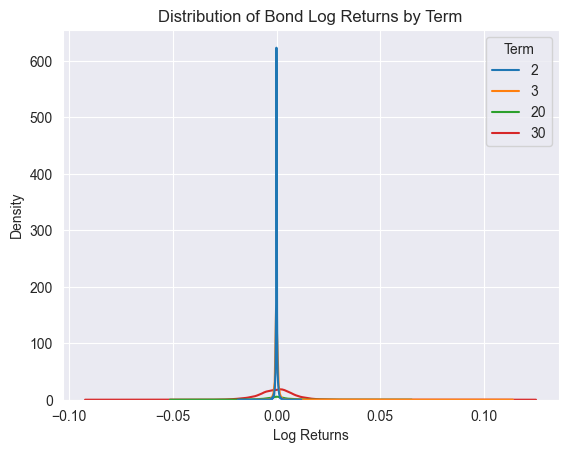

In [87]:
# df_processed['Term'] = df_processed['term'].astype(str)  # Convert term to string for better plotting
df_processed.reset_index(inplace=True)
sns.kdeplot(df_processed, x='bond_log_return', hue='Term')
# hide the legend
plt.title("Distribution of Bond Log Returns by Term")
plt.xlabel("Log Returns")


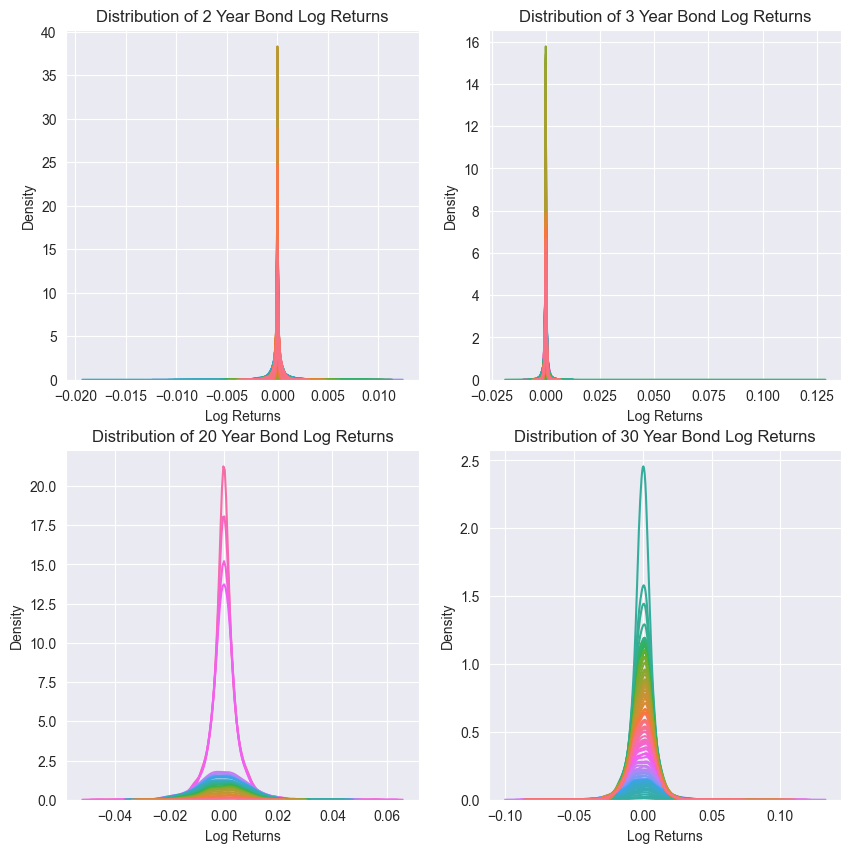

In [90]:
# create a 2 by 2 subplot for each term
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
i = 0
for term in terms:
    df_term = df_processed[df_processed['Term'] == f"{term}"]
    sns.kdeplot(df_term, x='bond_log_return', hue='bond', ax=axes[i], legend=False)
    axes[i].set_title(f"Distribution of {term} Year Bond Log Returns")
    axes[i].set_xlabel("Log Returns")
    axes[i].set_ylabel("Density")
    i += 1
    # axes[i].legend(title='Bond')
    # plt.show()